In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

np.set_printoptions(precision=3, suppress=True)
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import scale, StandardScaler

# Predict Nationality from Names
- In this exercise, we are going to get names of the European Parliment members from European Parliment website.
- We will use `xml.etree.ElementTree` library for turning an xml file in string format into xml file
- We will use `requests` library to request an`xml` file from a webpage

  - XML documents have sections, called elements, defined by a beginning and an ending tag. A tag is a markup construct that begins with < and ends with >. The characters between the start-tag and end-tag, if there are any, are the element's content. Elements can contain markup, including other elements, which are called "child elements".
  - The largest, top-level element is called the root, which contains all other elements.
  - Attributes are name–value pair that exist within a start-tag or empty-element tag. An XML attribute can only have a single value and each attribute can appear at most once on each element.
  

In [2]:
import xml.etree.ElementTree as ET

In [3]:
import requests

In [4]:
response = requests.get("https://www.europarl.europa.eu/meps/en/full-list/xml")

In [5]:
print(response.status_code)

print(response.headers['content-type'])

print(response.encoding)

print(response.text[:100])

200
application/xml;charset=UTF-8
UTF-8
<?xml version="1.0" encoding="UTF-8" standalone="yes"?><meps><mep><fullName>Mika AALTOLA</fullName><


response.text

- `fromstring()` parses XML from a string directly into an `Element`, which is the root element of the parsed tree.

In [6]:
data_xml = ET.fromstring(response.text)

In [7]:
data_xml.tag

'meps'

In [8]:
data_xml.attrib

{}

In [9]:
type(data_xml)

xml.etree.ElementTree.Element

In [10]:
len(data_xml)

719

In [11]:
root=data_xml
[elem.tag for elem in root.iter()];

In [12]:
#meps: members of european parliament
i=0
for child in data_xml.iter():
    print(child.tag, child.attrib)
    i=i+1
    if i==20:
        break

meps {}
mep {}
fullName {}
country {}
politicalGroup {}
id {}
nationalPoliticalGroup {}
mep {}
fullName {}
country {}
politicalGroup {}
id {}
nationalPoliticalGroup {}
mep {}
fullName {}
country {}
politicalGroup {}
id {}
nationalPoliticalGroup {}
mep {}


In [13]:
i=0
for child in data_xml.iter('fullName'):
    print(child.tag, child.text)
    i=i+1
    if i==20:
        break

fullName Mika AALTOLA
fullName Maravillas ABADÍA JOVER
fullName Magdalena ADAMOWICZ
fullName Georgios AFTIAS
fullName Oihane AGIRREGOITIA MARTÍNEZ
fullName Peter AGIUS
fullName Alex AGIUS SALIBA
fullName Galato ALEXANDRAKI
fullName Grégory ALLIONE
fullName Abir AL-SAHLANI
fullName Nikolaos ANADIOTIS
fullName Christine ANDERSON
fullName Li ANDERSSON
fullName Rasmus ANDRESEN
fullName Barry ANDREWS
fullName Vytenis Povilas ANDRIUKAITIS
fullName Mathilde ANDROUËT
fullName Marc ANGEL
fullName Gerolf ANNEMANS
fullName Lucia ANNUNZIATA


In [15]:
data_xml[0][0].text

'Mika AALTOLA'

In [16]:
data_xml[0][1].text

'Finland'

In [18]:
members_xml = data_xml.getchildren()

AttributeError: 'xml.etree.ElementTree.Element' object has no attribute 'getchildren'

- We are now turning the xml string file into a list

In [19]:
members_xml = list(data_xml)

In [20]:
members_xml[1][0].text

'Maravillas ABADÍA JOVER'

In [21]:
import pandas as pd
members_dict = [{i.tag: i.text for i in member} for member in members_xml]
members = pd.DataFrame(members_dict)

In [22]:
members_dict[:5]

[{'fullName': 'Mika AALTOLA',
  'country': 'Finland',
  'politicalGroup': "Group of the European People's Party (Christian Democrats)",
  'id': '256810',
  'nationalPoliticalGroup': 'Kansallinen Kokoomus'},
 {'fullName': 'Maravillas ABADÍA JOVER',
  'country': 'Spain',
  'politicalGroup': "Group of the European People's Party (Christian Democrats)",
  'id': '257043',
  'nationalPoliticalGroup': 'Partido Popular'},
 {'fullName': 'Magdalena ADAMOWICZ',
  'country': 'Poland',
  'politicalGroup': "Group of the European People's Party (Christian Democrats)",
  'id': '197490',
  'nationalPoliticalGroup': 'Independent'},
 {'fullName': 'Georgios AFTIAS',
  'country': 'Greece',
  'politicalGroup': "Group of the European People's Party (Christian Democrats)",
  'id': '256820',
  'nationalPoliticalGroup': 'Nea Demokratia'},
 {'fullName': 'Oihane AGIRREGOITIA MARTÍNEZ',
  'country': 'Spain',
  'politicalGroup': 'Renew Europe Group',
  'id': '256987',
  'nationalPoliticalGroup': 'Partido Nacionalis

In [23]:
members[:20]

,fullName,country,politicalGroup,id,nationalPoliticalGroup
0,Mika AALTOLA,Finland,Group of the European People's Party (Christia...,256810,Kansallinen Kokoomus
1,Maravillas ABADÍA JOVER,Spain,Group of the European People's Party (Christia...,257043,Partido Popular
2,Magdalena ADAMOWICZ,Poland,Group of the European People's Party (Christia...,197490,Independent
3,Georgios AFTIAS,Greece,Group of the European People's Party (Christia...,256820,Nea Demokratia
4,Oihane AGIRREGOITIA MARTÍNEZ,Spain,Renew Europe Group,256987,Partido Nacionalista Vasco
5,Peter AGIUS,Malta,Group of the European People's Party (Christia...,113523,Partit Nazzjonalista
6,Alex AGIUS SALIBA,Malta,Group of the Progressive Alliance of Socialist...,197403,Partit Laburista
7,Galato ALEXANDRAKI,Greece,European Conservatives and Reformists Group,256956,Elliniki Lusi-Greek Solution
8,Grégory ALLIONE,France,Renew Europe Group,256869,Renaissance
9,Abir AL-SAHLANI,Sweden,Renew Europe Group,197400,Centerpartiet


# Predicting nationalities from names

In [24]:
members.shape

(719, 5)

- Create a bar graph showing the ratio of nationalities in the European parliament

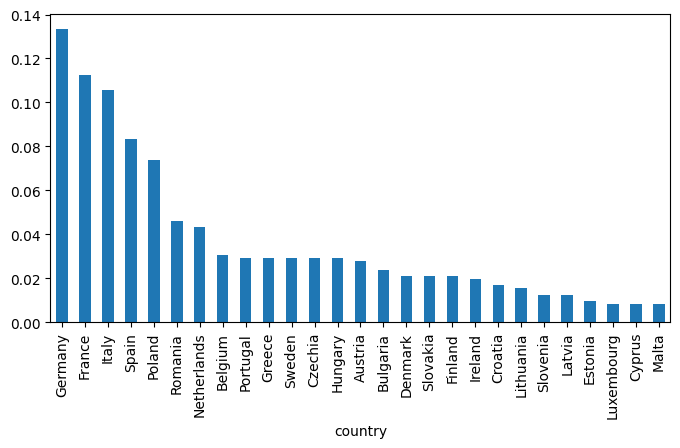

In [25]:
y_mem = members.country
data_mem = members.fullName
plt.figure(figsize=(8, 4))
(y_mem.value_counts() / y_mem.size).plot(kind='bar');

- print the value counts of the members per country

In [26]:
tt=y_mem.value_counts()[:8]

In [27]:
tt.values, tt.index

(array([96, 81, 76, 60, 53, 33, 31, 22]),
 Index(['Germany', 'France', 'Italy', 'Spain', 'Poland', 'Romania',
        'Netherlands', 'Belgium'],
       dtype='object', name='country'))

- Get the names of the first 8 countries with the largest number of meps

In [28]:
large = y_mem.value_counts()[:8].index
large

Index(['Germany', 'France', 'Italy', 'Spain', 'Poland', 'Romania',
       'Netherlands', 'Belgium'],
      dtype='object', name='country')

- create a data with the parliament members in the first eight countries
- split data into test and train datasets

In [29]:
mask = y_mem.isin(large)
data_mem = data_mem[mask]
y_mem = y_mem[mask]

In [30]:
mask

0      False
1       True
2       True
3      False
4       True
       ...  
714     True
715     True
716     True
717    False
718    False
Name: country, Length: 719, dtype: bool

In [31]:
(y_mem.value_counts() / y_mem.size)

country
Germany        0.212389
France         0.179204
Italy          0.168142
Spain          0.132743
Poland         0.117257
Romania        0.073009
Netherlands    0.068584
Belgium        0.048673
Name: count, dtype: float64

In [32]:
data_mem.shape

(452,)

In [33]:
text_mem_train, text_mem_test, y_mem_train, y_mem_test = \
train_test_split(data_mem, y_mem,  stratify=y_mem, random_state=0)

- create a pipeline of `countvectorizer` and `logisticregressioncv`
- report the cross validation scores

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegressionCV
bow_pipe = make_pipeline(CountVectorizer(), LogisticRegressionCV())
cross_val_score(bow_pipe, text_mem_train, y_mem_train, cv=5,\
                scoring='f1_macro')

array([0.356, 0.27 , 0.301, 0.324, 0.391])

- Repeat the same procedure, with vectorizer having the parameter of analyzer="char_wb"

 - analyzer{‘word’, ‘char’, ‘char_wb’} or callable, default=’word’ Whether the feature should be made of word n-gram or character n-grams. Option ‘char_wb’ creates character n-grams only from text inside word boundaries; n-grams at the edges of words are padded with space.

In [35]:
char_pipe = make_pipeline(CountVectorizer(analyzer="char_wb",\
ngram_range=(1, 4)), LogisticRegressionCV(solver='liblinear'))
cross_val_score(char_pipe, text_mem_train, y_mem_train, cv=5, scoring='f1_macro')

array([0.425, 0.405, 0.441, 0.46 , 0.405])

In [36]:
char_pipe.fit(text_mem_train, y_mem_train)

Pipeline(steps=[('countvectorizer',
                 CountVectorizer(analyzer='char_wb', ngram_range=(1, 4))),
                ('logisticregressioncv',
                 LogisticRegressionCV(solver='liblinear'))])

- print the top 20 most important and least important n-grams

In [37]:
def plot_important_features(coef, feature_names, top_n=20,\
                            ax=None, rotation=60):
    if ax is None:
        ax = plt.gca()
    inds = np.argsort(coef)
    low = inds[:top_n]
    high = inds[-top_n:]
    important = np.hstack([low, high])
    myrange = range(len(important))
    colors = ['red'] * top_n + ['blue'] * top_n
    
    ax.bar(myrange, coef[important], color=colors)
    ax.set_xticks(myrange)
    ax.set_xticklabels(feature_names[important],\
                       rotation=rotation, ha="right")
    ax.set_xlim(-.7, 2 * top_n)
    ax.set_frame_on(False)

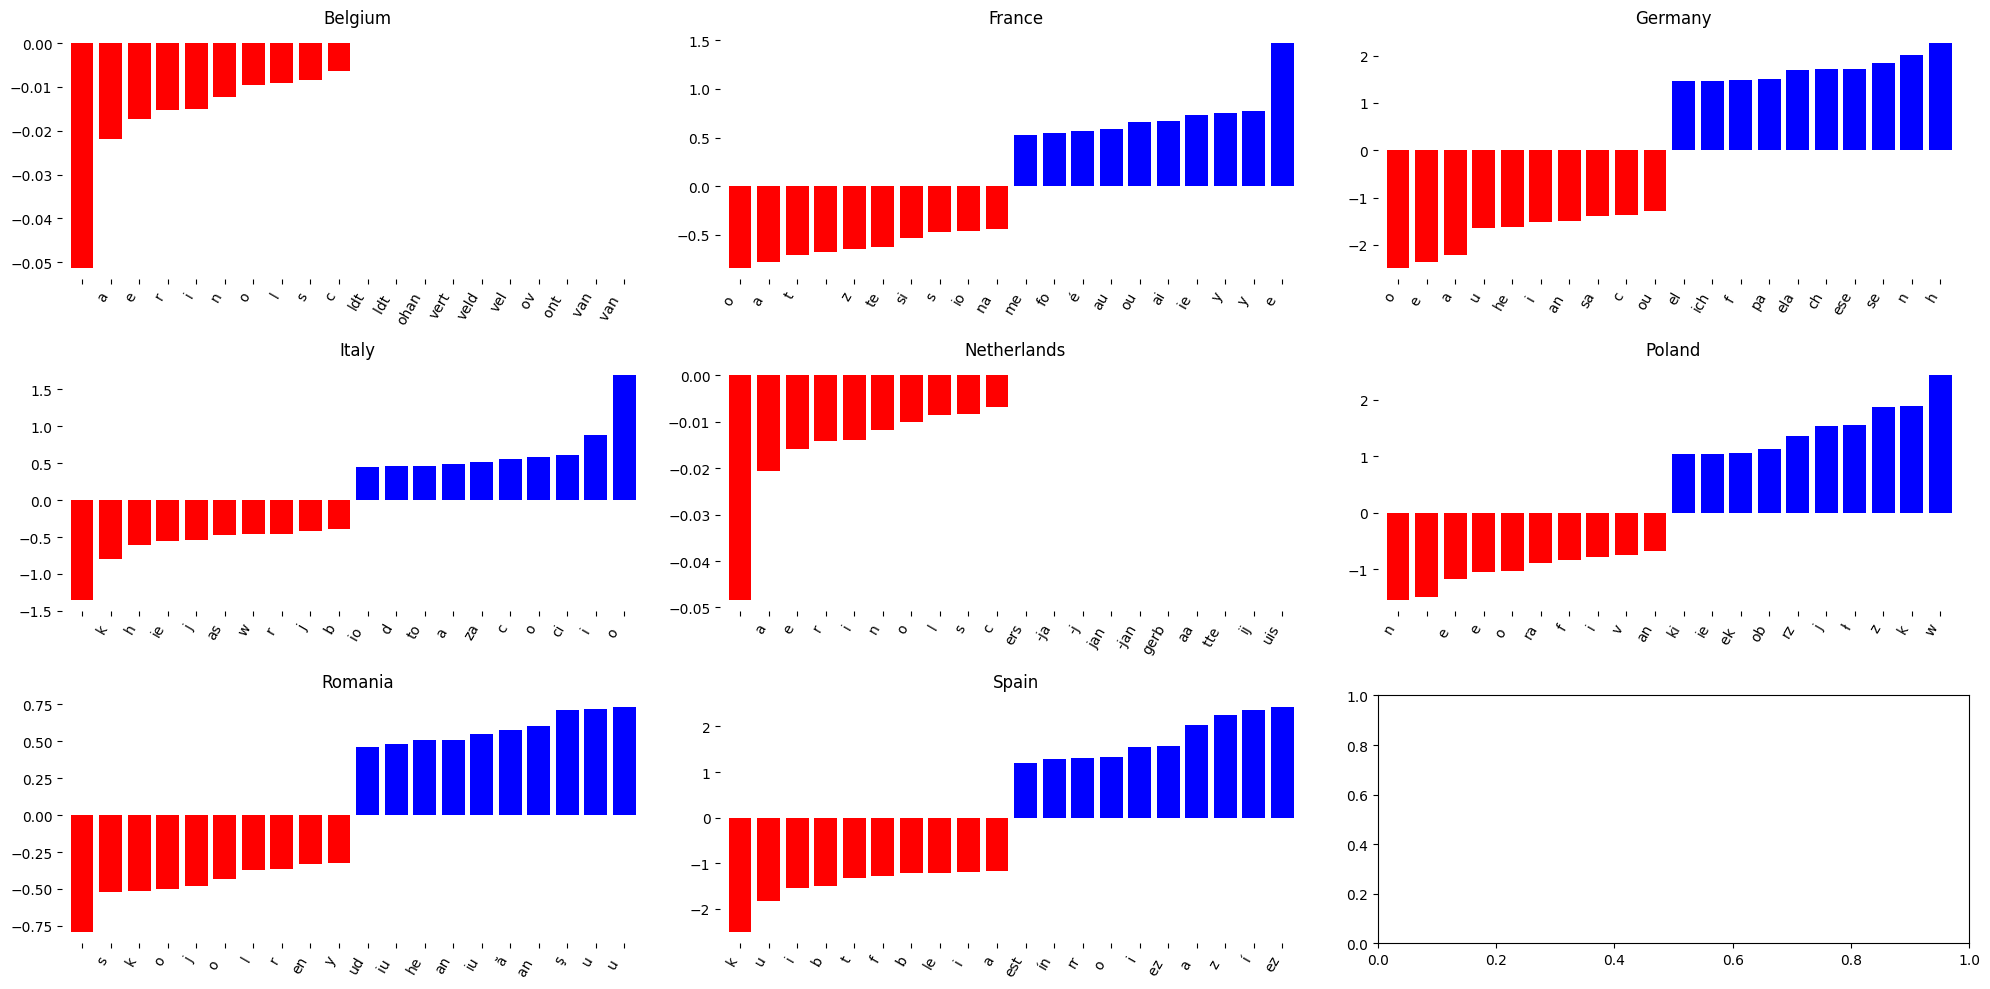

In [38]:
lr = char_pipe.named_steps['logisticregressioncv']
feature_names = np.array(char_pipe.named_steps\
                         ['countvectorizer'].get_feature_names_out())
n_classes = len(lr.classes_)
fig, axes = plt.subplots(n_classes // 3 + 1, 3, figsize=(20, 10))
for ax, coef, label in zip(axes.ravel(), lr.coef_, lr.classes_):
    ax.set_title(label)
    plot_important_features(coef, feature_names, top_n=10, ax=ax)
    
plt.tight_layout()

- Now make a gridsearch over logistic regression, countvectorizer n-grams, min_df and normalizer

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Normalizer

param_grid = {"logisticregression__C": [100, 10, 1, 0.1, 0.001],
              "countvectorizer__ngram_range": [(1, 1), (1, 2), (1, 5), (1, 7),
                                               (2, 3), (2, 5), (3, 8), (5, 5)],
              "countvectorizer__min_df": [1, 2, 3],
              "normalizer": [None, Normalizer()]
             }
grid = GridSearchCV(make_pipeline(CountVectorizer(analyzer="char"),\
Normalizer(), LogisticRegression(solver='liblinear')),\
param_grid=param_grid, cv=10, \
scoring="f1_macro",return_train_score=True
                   )


In [40]:
grid.fit(text_mem_train, y_mem_train)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('countvectorizer',
                                        CountVectorizer(analyzer='char')),
                                       ('normalizer', Normalizer()),
                                       ('logisticregression',
                                        LogisticRegression(solver='liblinear'))]),
             param_grid={'countvectorizer__min_df': [1, 2, 3],
                         'countvectorizer__ngram_range': [(1, 1), (1, 2),
                                                          (1, 5), (1, 7),
                                                          (2, 3), (2, 5),
                                                          (3, 8), (5, 5)],
                         'logisticregression__C': [100, 10, 1, 0.1, 0.001],
                         'normalizer': [None, Normalizer()]},
             return_train_score=True, scoring='f1_macro')

In [40]:
grid.best_score_

0.6098917747843832

In [41]:
grid.best_params_

{'countvectorizer__min_df': 1,
 'countvectorizer__ngram_range': (1, 2),
 'logisticregression__C': 1,
 'normalizer': None}

In [42]:
results = pd.DataFrame(grid.cv_results_)
res_pivot = results.pivot_table(values=['mean_test_score', 'mean_train_score'],
                                index=["param_countvectorizer__ngram_range", "param_logisticregression__C",
                                       "param_countvectorizer__min_df"])

In [43]:
res_pivot.mean_test_score

param_countvectorizer__ngram_range  param_logisticregression__C  param_countvectorizer__min_df
(1, 1)                              0.001                        1                                0.107363
                                                                 2                                0.107363
                                                                 3                                0.107363
                                    0.100                        1                                0.290589
                                                                 2                                0.292350
                                                                                                    ...   
(5, 5)                              10.000                       2                                0.264880
                                                                 3                                0.171734
                                    100.000      

In [44]:
bla = res_pivot.mean_test_score.unstack(["param_countvectorizer__ngram_range"])
bla = bla.swaplevel().sort_index()
bla.index.names = ['min_df', 'C']
bla.style.background_gradient(cmap="viridis")

In [45]:
lr = grid.best_estimator_.named_steps['logisticregression']
feature_names = np.array(grid.best_estimator_.\
    named_steps['countvectorizer'].get_feature_names())
n_classes = len(lr.classes_)
fig, axes = plt.subplots(n_classes, figsize=(10, 20))
for ax, coef, label in zip(axes.ravel(), lr.coef_, lr.classes_):
    ax.set_title(label)
    plot_important_features(coef, \
feature_names, top_n=20, ax=ax)
    
plt.tight_layout()

AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'